In [1]:
! pip install pandasql

  Preparing metadata (setup.py) ... done
  Created wheel for pandasql: filename=pandasql-0.7.3-py3-none-any.whl size=26773 sha256=ea791183b18a85808d994bf58faf2ac06f430f6c5dc4c87baf195fde10a43a6f
  Stored in directory: /root/.cache/pip/wheels/15/a1/e7/6f92f295b5272ae5c02365e6b8fa19cb93f16a537090a1cf27
Successfully built pandasql


In [2]:
from google.colab import files
uploaded = files.upload()

import io
import pandas as pd
df_raw = pd.read_csv(io.BytesIO(list(uploaded.values())[0]))
df_raw.to_csv('expectedpayerpdd.csv', index=False)
print("File uploaded successfully")

Saving expectedpayerpdd.csv to expectedpayerpdd.csv
File uploaded successfully


Loading data...
Loaded 6,832 rows
Years available: 2012 to 2024
Counties: 60


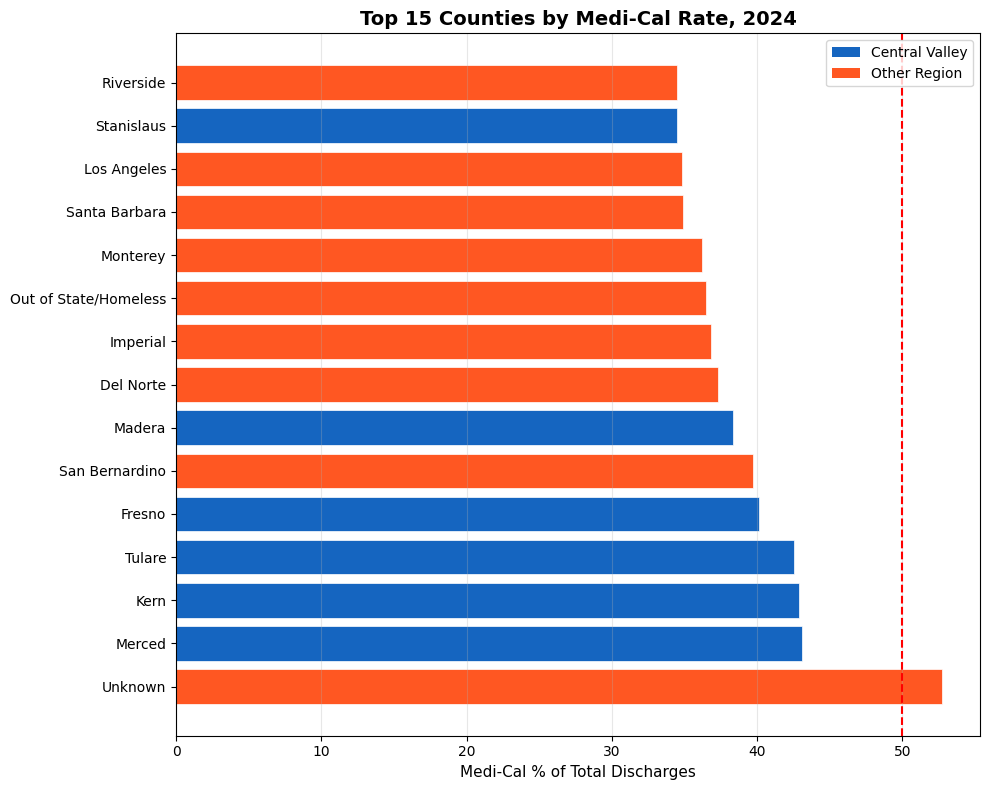

Saved as medi_cal_by_county.png


In [15]:
df = load_data('expectedpayerpdd.csv')

def normalize_payer(payer):
    if payer in ['Private Coverage', 'Private Health Insurance']:
        return 'Private Coverage'
    if payer in ['Self-Pay', 'Self-Pay or Uninsured']:
        return 'Self-Pay'
    if payer in ['Other Payer', 'All Other Payers', 'Other Indigent', 'Invalid', 'Invalid/Blank']:
        return 'Other'
    return payer

df['payer'] = df['payer'].apply(normalize_payer)

fig, ax = plt.subplots(figsize=(10, 8))

medi_cal = q2_medi_cal_by_county(df, df['year'].max())

central_valley = ['Fresno','Kern','Kings','Madera','Merced',
                  'Sacramento','San Joaquin','Stanislaus','Tulare','Yolo']

bar_colors = ['#1565C0' if c in central_valley else '#FF5722' for c in medi_cal['county']]

ax.barh(medi_cal['county'], medi_cal['medi_cal_pct'],
        color=bar_colors, edgecolor='white', linewidth=0.5)

ax.axvline(x=50, color='red', linestyle='--', linewidth=1.5, label='50% threshold')

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#1565C0', label='Central Valley'),
    Patch(facecolor='#FF5722', label='Other Region')
]
ax.legend(handles=legend_elements, fontsize=10)

ax.set_xlabel('Medi-Cal % of Total Discharges', fontsize=11)
ax.set_title(f'Top 15 Counties by Medi-Cal Rate, {df["year"].max()}',
             fontsize=14, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('medi_cal_by_county.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved as medi_cal_by_county.png")

Loading data...
Loaded 6,832 rows
Years available: 2012 to 2024
Counties: 60


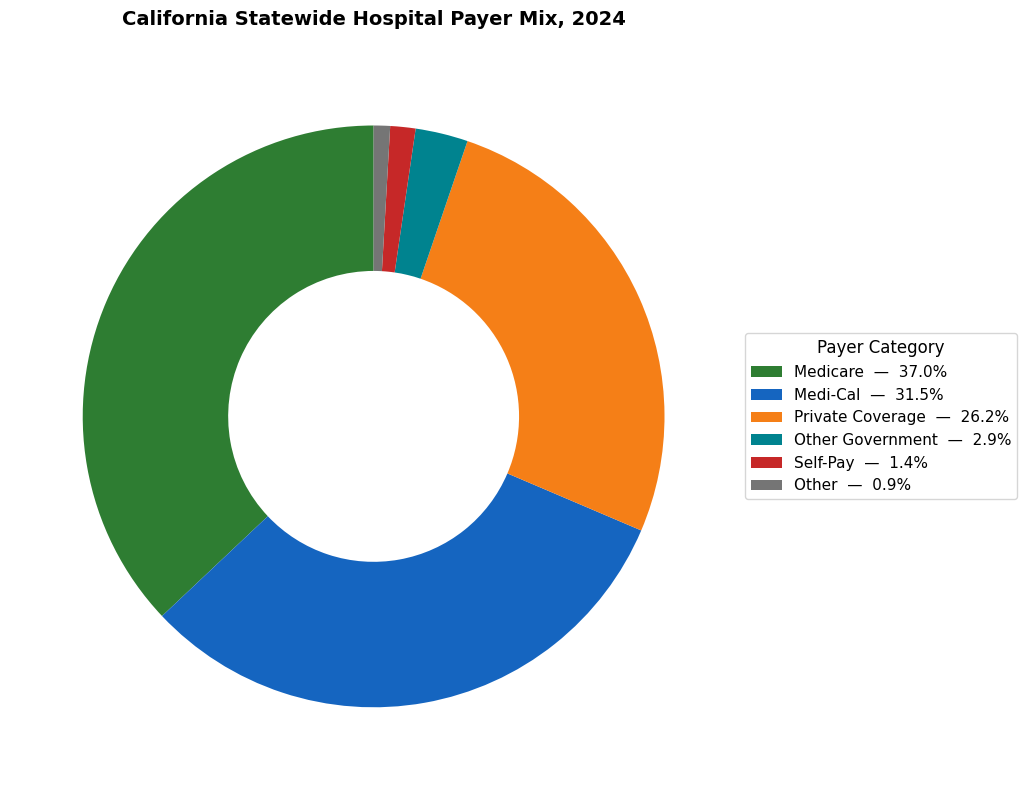

Saved as payer_mix_donut.png


In [14]:
df = load_data('expectedpayerpdd.csv')

def normalize_payer(payer):
    if payer in ['Private Coverage', 'Private Health Insurance']:
        return 'Private Coverage'
    if payer in ['Self-Pay', 'Self-Pay or Uninsured']:
        return 'Self-Pay'
    if payer in ['Other Payer', 'All Other Payers', 'Other Indigent', 'Invalid', 'Invalid/Blank']:
        return 'Other'
    return payer

df['payer'] = df['payer'].apply(normalize_payer)

fig, ax = plt.subplots(figsize=(10, 8))

state = q1_statewide_payer_mix(df, df['year'].max())
state_grouped = state.groupby('payer')['total_discharges'].sum().reset_index()
state_grouped = state_grouped.sort_values('total_discharges', ascending=False)

total = state_grouped['total_discharges'].sum()
state_grouped['pct'] = state_grouped['total_discharges'] / total * 100

PAYER_COLORS = {
    'Medi-Cal': '#1565C0',
    'Medicare': '#2E7D32',
    'Private Coverage': '#F57F17',
    'Self-Pay': '#C62828',
    'County Indigent Program': '#6A1B9A',
    'Other Government': '#00838F',
    "Workers' Compensation": '#455A64',
    'Other': '#757575'
}

colors = [PAYER_COLORS.get(p, '#757575') for p in state_grouped['payer']]

# Donut chart with no percentage labels on slices at all
wedges, texts = ax.pie(
    state_grouped['total_discharges'],
    colors=colors,
    startangle=90,
    wedgeprops=dict(width=0.5)  # This makes it a donut
)

# All percentages go in the legend, clearly readable
labels = [
    f"{row['payer']}  —  {row['pct']:.1f}%"
    for _, row in state_grouped.iterrows()
]

ax.legend(
    wedges,
    labels,
    title='Payer Category',
    loc='center left',
    bbox_to_anchor=(1, 0, 0.5, 1),
    fontsize=11,
    title_fontsize=12
)

ax.set_title(
    f'California Statewide Hospital Payer Mix, {df["year"].max()}',
    fontsize=14, fontweight='bold', pad=20
)

plt.tight_layout()
plt.savefig('payer_mix_donut.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved as payer_mix_donut.png")

Loading data...
Loaded 6,832 rows
Years available: 2012 to 2024
Counties: 60


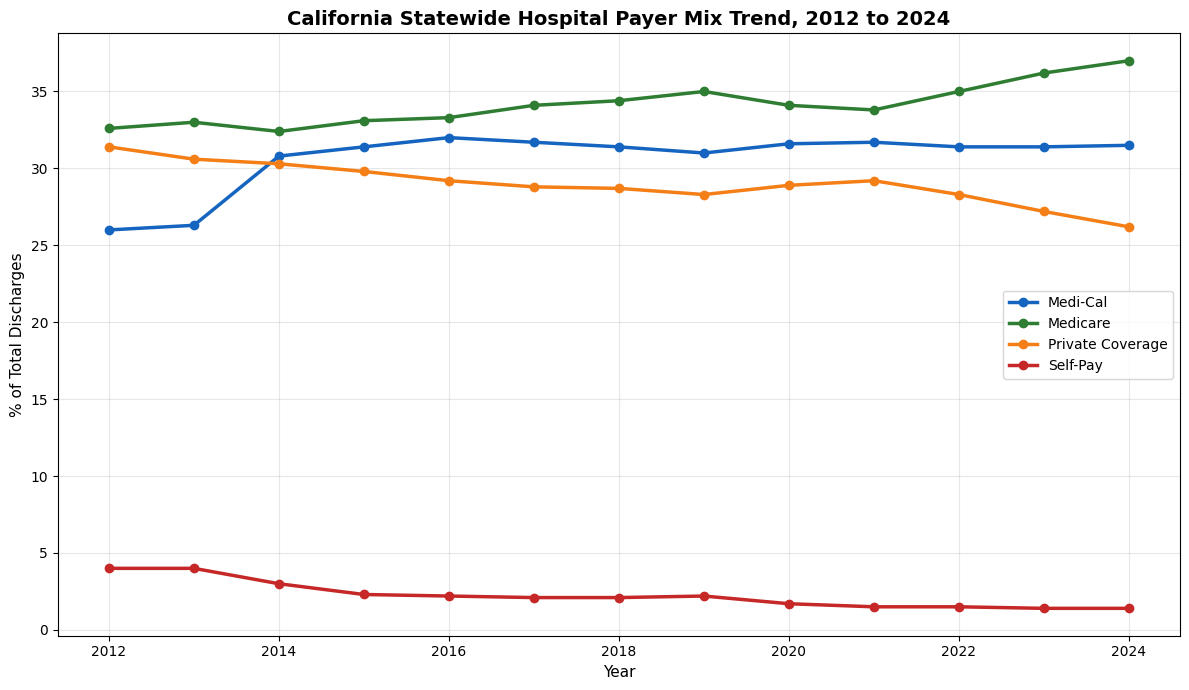

Saved as payer_mix_trend.png


In [16]:
df = load_data('expectedpayerpdd.csv')

def normalize_payer(payer):
    if payer in ['Private Coverage', 'Private Health Insurance']:
        return 'Private Coverage'
    if payer in ['Self-Pay', 'Self-Pay or Uninsured']:
        return 'Self-Pay'
    if payer in ['Other Payer', 'All Other Payers', 'Other Indigent', 'Invalid', 'Invalid/Blank']:
        return 'Other'
    return payer

df['payer'] = df['payer'].apply(normalize_payer)

fig, ax = plt.subplots(figsize=(12, 7))

trend = q5_payer_trend(df)

PAYER_COLORS = {
    'Medi-Cal': '#1565C0',
    'Medicare': '#2E7D32',
    'Private Coverage': '#F57F17',
    'Self-Pay': '#C62828'
}

for payer in ['Medi-Cal', 'Medicare', 'Private Coverage', 'Self-Pay']:
    payer_data = trend[trend['payer'] == payer].sort_values('year')
    ax.plot(
        payer_data['year'],
        payer_data['pct_of_total'],
        marker='o',
        linewidth=2.5,
        markersize=6,
        label=payer,
        color=PAYER_COLORS.get(payer)
    )

ax.set_xlabel('Year', fontsize=11)
ax.set_ylabel('% of Total Discharges', fontsize=11)
ax.set_title('California Statewide Hospital Payer Mix Trend, 2012 to 2024',
             fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('payer_mix_trend.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved as payer_mix_trend.png")

Loading data...
Loaded 6,832 rows
Years available: 2012 to 2024
Counties: 60


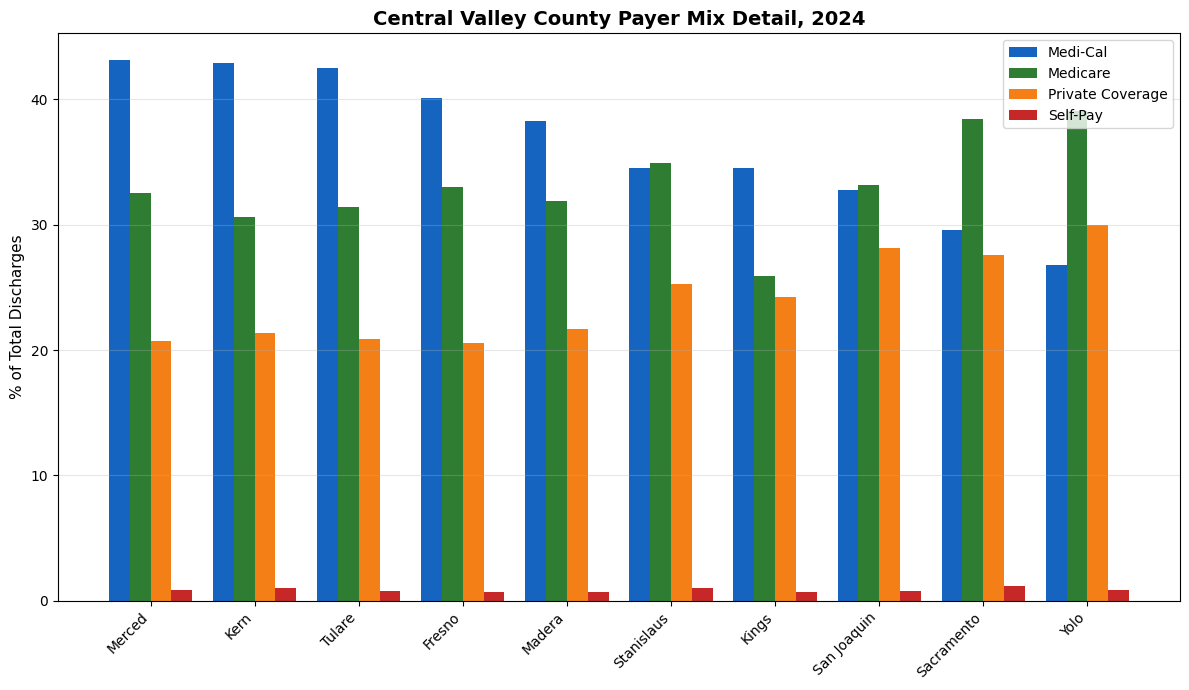

Saved as central_valley_payer_detail.png


In [17]:
df = load_data('expectedpayerpdd.csv')

def normalize_payer(payer):
    if payer in ['Private Coverage', 'Private Health Insurance']:
        return 'Private Coverage'
    if payer in ['Self-Pay', 'Self-Pay or Uninsured']:
        return 'Self-Pay'
    if payer in ['Other Payer', 'All Other Payers', 'Other Indigent', 'Invalid', 'Invalid/Blank']:
        return 'Other'
    return payer

df['payer'] = df['payer'].apply(normalize_payer)

fig, ax = plt.subplots(figsize=(12, 7))

cv = q6_central_valley_detail(df, df['year'].max())

x = np.arange(len(cv))
width = 0.2

ax.bar(x - width*1.5, cv['medi_cal_pct'], width, label='Medi-Cal', color='#1565C0')
ax.bar(x - width*0.5, cv['medicare_pct'], width, label='Medicare', color='#2E7D32')
ax.bar(x + width*0.5, cv['private_pct'], width, label='Private Coverage', color='#F57F17')
ax.bar(x + width*1.5, cv['self_pay_pct'], width, label='Self-Pay', color='#C62828')

ax.set_xticks(x)
ax.set_xticklabels(cv['county'], rotation=45, ha='right', fontsize=10)
ax.set_ylabel('% of Total Discharges', fontsize=11)
ax.set_title(f'Central Valley County Payer Mix Detail, {df["year"].max()}',
             fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('central_valley_payer_detail.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved as central_valley_payer_detail.png")

In [18]:
print("=" * 60)
print("SQL QUERIES USED IN THIS ANALYSIS")
print("=" * 60)

print("""
-- Query 1: Statewide Payer Mix
SELECT
    payer,
    SUM(discharges) AS total_discharges,
    ROUND(100.0 * SUM(discharges) /
        (SELECT SUM(discharges) FROM hospital_data WHERE year = 2024), 1)
    AS pct_of_total
FROM hospital_data
WHERE year = 2024
GROUP BY payer
ORDER BY total_discharges DESC;

-- Query 2: Top Counties by Medi-Cal Rate
SELECT
    county,
    SUM(discharges) AS total_discharges,
    SUM(CASE WHEN payer = 'Medi-Cal' THEN discharges ELSE 0 END) AS medi_cal_discharges,
    ROUND(100.0 * SUM(CASE WHEN payer = 'Medi-Cal' THEN discharges ELSE 0 END)
        / SUM(discharges), 1) AS medi_cal_pct
FROM hospital_data
WHERE year = 2024
GROUP BY county
HAVING SUM(discharges) > 100
ORDER BY medi_cal_pct DESC
LIMIT 15;

-- Query 3: Top Counties by Self-Pay Rate
SELECT
    county,
    SUM(discharges) AS total_discharges,
    SUM(CASE WHEN payer = 'Self-Pay' THEN discharges ELSE 0 END) AS self_pay_discharges,
    ROUND(100.0 * SUM(CASE WHEN payer = 'Self-Pay' THEN discharges ELSE 0 END)
        / SUM(discharges), 1) AS self_pay_pct
FROM hospital_data
WHERE year = 2024
GROUP BY county
HAVING SUM(discharges) > 100
ORDER BY self_pay_pct DESC
LIMIT 15;

-- Query 4: Regional Payer Mix Comparison
SELECT
    CASE
        WHEN county IN ('Fresno','Kern','Kings','Madera','Merced',
                        'Sacramento','San Joaquin','Stanislaus','Tulare','Yolo')
        THEN 'Central Valley'
        WHEN county IN ('Alameda','Contra Costa','Marin','San Francisco',
                        'San Mateo','Santa Clara','Sonoma')
        THEN 'Bay Area'
        WHEN county IN ('Los Angeles','Orange','Riverside',
                        'San Bernardino','San Diego')
        THEN 'Southern California'
    END AS region,
    payer,
    SUM(discharges) AS discharges
FROM hospital_data
WHERE year = 2024
GROUP BY region, payer
HAVING region IS NOT NULL
ORDER BY region, discharges DESC;

-- Query 5: Payer Mix Trend Using Subquery for Year Totals
SELECT
    h.year,
    h.payer,
    SUM(h.discharges) AS discharges,
    ROUND(100.0 * SUM(h.discharges) / totals.yearly_total, 1) AS pct_of_total
FROM hospital_data h
JOIN (
    SELECT year, SUM(discharges) AS yearly_total
    FROM hospital_data
    GROUP BY year
) totals ON h.year = totals.year
WHERE h.payer IN ('Medi-Cal', 'Medicare', 'Private Coverage', 'Self-Pay')
GROUP BY h.year, h.payer
ORDER BY h.year, h.payer;

-- Query 6: Central Valley County Detail
SELECT
    county,
    SUM(discharges) AS total_discharges,
    ROUND(100.0 * SUM(CASE WHEN payer = 'Medi-Cal' THEN discharges ELSE 0 END) / SUM(discharges), 1) AS medi_cal_pct,
    ROUND(100.0 * SUM(CASE WHEN payer = 'Medicare' THEN discharges ELSE 0 END) / SUM(discharges), 1) AS medicare_pct,
    ROUND(100.0 * SUM(CASE WHEN payer = 'Private Coverage' THEN discharges ELSE 0 END) / SUM(discharges), 1) AS private_pct,
    ROUND(100.0 * SUM(CASE WHEN payer = 'Self-Pay' THEN discharges ELSE 0 END) / SUM(discharges), 1) AS self_pay_pct
FROM hospital_data
WHERE year = 2024
AND county IN ('Fresno','Kern','Kings','Madera','Merced',
               'Sacramento','San Joaquin','Stanislaus','Tulare','Yolo')
GROUP BY county
ORDER BY medi_cal_pct DESC;
""")

SQL QUERIES USED IN THIS ANALYSIS

-- Query 1: Statewide Payer Mix
SELECT
    payer,
    SUM(discharges) AS total_discharges,
    ROUND(100.0 * SUM(discharges) /
        (SELECT SUM(discharges) FROM hospital_data WHERE year = 2024), 1)
    AS pct_of_total
FROM hospital_data
WHERE year = 2024
GROUP BY payer
ORDER BY total_discharges DESC;

-- Query 2: Top Counties by Medi-Cal Rate
SELECT
    county,
    SUM(discharges) AS total_discharges,
    SUM(CASE WHEN payer = 'Medi-Cal' THEN discharges ELSE 0 END) AS medi_cal_discharges,
    ROUND(100.0 * SUM(CASE WHEN payer = 'Medi-Cal' THEN discharges ELSE 0 END)
        / SUM(discharges), 1) AS medi_cal_pct
FROM hospital_data
WHERE year = 2024
GROUP BY county
HAVING SUM(discharges) > 100
ORDER BY medi_cal_pct DESC
LIMIT 15;

-- Query 3: Top Counties by Self-Pay Rate
SELECT
    county,
    SUM(discharges) AS total_discharges,
    SUM(CASE WHEN payer = 'Self-Pay' THEN discharges ELSE 0 END) AS self_pay_discharges,
    ROUND(100.0 * SUM(CASE WHEN 